In [2]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import os
from google.colab import files

print(" Libraries installed and imported successfully!")


 Libraries installed and imported successfully!


In [7]:
print("=" * 60)
print(" PLEASE UPLOAD YOUR DATASET FILE")
print("=" * 60)
print("\nClick the 'Choose Files' button below and select your dataset file.")
print("Your dataset should be named 'urldata.csv' or similar.\n")

# Upload the file
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n File '{filename}' uploaded successfully!")

# Load the dataset
data = pd.read_csv(filename)
print(f"\n Dataset loaded successfully!")
print(f" Shape: {data.shape[0]} rows × {data.shape[1]} columns")

# Show first few rows
print("\n First 5 rows of data:")
print(data.head())

print("\n Column names:")
print(data.columns.tolist())

# Check the target column name
print("\n Looking for target column...")
target_column = None
possible_targets = ['phishing', 'Result', 'label', 'target', 'class']

for col in possible_targets:
    if col in data.columns:
        target_column = col
        print(f" Found target column: '{target_column}'")
        break

if target_column is None:
    print(" Could not automatically find target column.")
    print("Available columns:", data.columns.tolist())
    target_column = input("Please type the exact name of the target column: ")

 PLEASE UPLOAD YOUR DATASET FILE

Click the 'Choose Files' button below and select your dataset file.
Your dataset should be named 'urldata.csv' or similar.



Saving urldata.csv.csv to urldata.csv.csv

 File 'urldata.csv.csv' uploaded successfully!

 Dataset loaded successfully!
 Shape: 88647 rows × 112 columns

 First 5 rows of data:
   qty_dot_url  qty_hyphen_url  qty_underline_url  qty_slash_url  \
0            3               0                  0              1   
1            5               0                  1              3   
2            2               0                  0              1   
3            4               0                  2              5   
4            2               0                  0              0   

   qty_questionmark_url  qty_equal_url  qty_at_url  qty_and_url  \
0                     0              0           0            0   
1                     0              3           0            2   
2                     0              0           0            0   
3                     0              0           0            0   
4                     0              0           0            0   

   qty_exc


 DATA EXPLORATION & CLEANING

 Missing values in each column:
qty_dot_url             0
qty_hyphen_url          0
qty_underline_url       0
qty_slash_url           0
qty_questionmark_url    0
                       ..
qty_redirects           0
url_google_index        0
domain_google_index     0
url_shortened           0
phishing                0
Length: 112, dtype: int64

 Dataset statistics:
        qty_dot_url  qty_hyphen_url  qty_underline_url  qty_slash_url  \
count  88647.000000    88647.000000       88647.000000   88647.000000   
mean       2.191343        0.328810           0.113879       1.281781   
std        1.235636        1.119286           0.657767       1.893929   
min        1.000000        0.000000           0.000000       0.000000   
25%        2.000000        0.000000           0.000000       0.000000   
50%        2.000000        0.000000           0.000000       0.000000   
75%        2.000000        0.000000           0.000000       2.000000   
max       24.000000

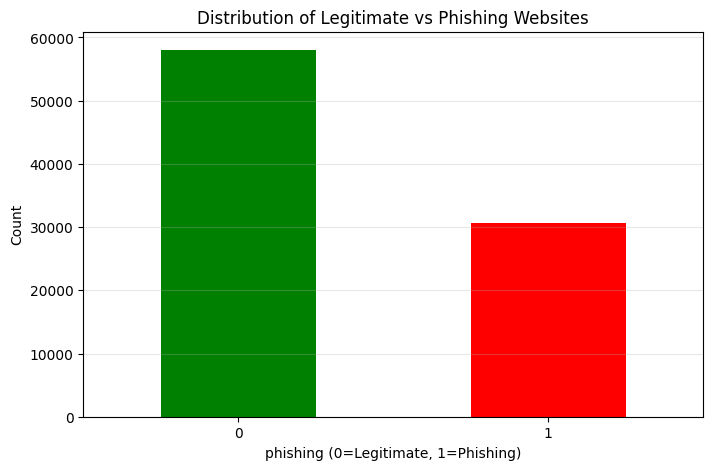


 Duplicate rows: 1438
 Removed 1438 duplicates. Rows after removing duplicates: 87209


In [8]:
print("\n" + "=" * 60)
print(" DATA EXPLORATION & CLEANING")
print("=" * 60)

# Check for missing values
print("\n Missing values in each column:")
print(data.isnull().sum())

# Get basic statistics
print("\n Dataset statistics:")
print(data.describe())

# Check target distribution
if target_column in data.columns:
    print(f"\n Target distribution ('{target_column}'):")
    print(data[target_column].value_counts())

    # Visualize target distribution
    plt.figure(figsize=(8,5))
    data[target_column].value_counts().plot(kind='bar', color=['green', 'red'])
    plt.title('Distribution of Legitimate vs Phishing Websites')
    plt.xlabel(f'{target_column} (0=Legitimate, 1=Phishing)')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print(f" Target column '{target_column}' not found in dataset.")
    print("Available columns:", data.columns.tolist())

# Check for duplicates
duplicates = data.duplicated().sum()
print(f"\n Duplicate rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    data = data.drop_duplicates()
    print(f" Removed {duplicates} duplicates. Rows after removing duplicates: {data.shape[0]}")
else:
    print(" No duplicates found.")

In [9]:
print("\n" + "=" * 60)
print(" FEATURE ENGINEERING & DATA PREPARATION")
print("=" * 60)

# Verify target column exists
if target_column not in data.columns:
    print(f" ERROR: Target column '{target_column}' not found!")
    print("Please check the column names and update the target_column variable.")
    print("Available columns:", data.columns.tolist())
    raise ValueError(f"Target column '{target_column}' not found")

# Separate features and target
X = data.drop(target_column, axis=1)  # Features
y = data[target_column]                # Target

print(f"\n Features shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f" Number of features: {X.shape[1]}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n Training set size: {X_train.shape[0]}")
print(f" Testing set size: {X_test.shape[0]}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature scaling completed!")

# Save feature names for later (IMPORTANT!)
feature_names = X.columns.tolist()
print(f"\n Saved {len(feature_names)} feature names")


 FEATURE ENGINEERING & DATA PREPARATION

 Features shape: (87209, 111)
 Target shape: (87209,)
 Number of features: 111

 Training set size: 69767
 Testing set size: 17442
 Feature scaling completed!

 Saved 111 feature names



 MODEL TRAINING
 Training Random Forest Classifier...
 Model training completed!

 Model Accuracy: 96.65%

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     11364
           1       0.95      0.96      0.95      6078

    accuracy                           0.97     17442
   macro avg       0.96      0.96      0.96     17442
weighted avg       0.97      0.97      0.97     17442



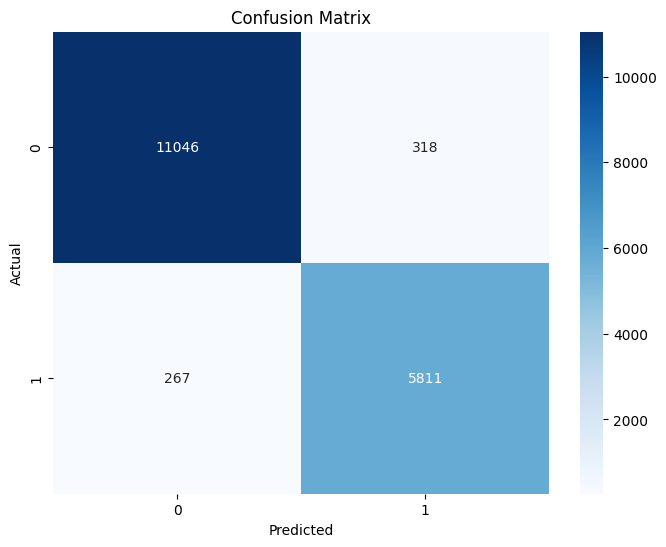


 Top 10 Most Important Features:
                     feature  importance
57          directory_length    0.116831
100   time_domain_activation    0.063304
55      qty_dollar_directory    0.047719
58              qty_dot_file    0.044563
43       qty_slash_directory    0.042858
18                length_url    0.033634
3              qty_slash_url    0.032610
42   qty_underline_directory    0.025107
75               file_length    0.024683
64               qty_at_file    0.024080


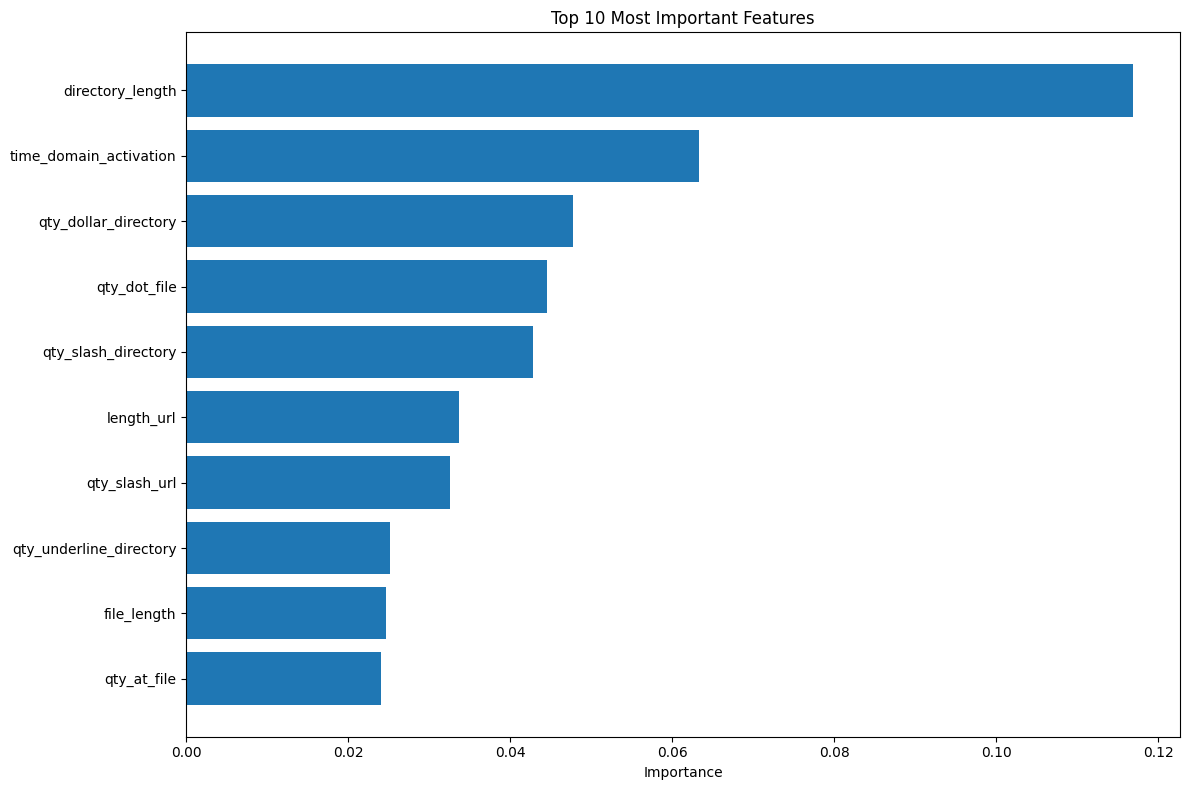

In [10]:
print("\n" + "=" * 60)
print(" MODEL TRAINING")
print("=" * 60)

# Create and train the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print(" Training Random Forest Classifier...")
model.fit(X_train_scaled, y_train)
print(" Model training completed!")

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Model Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("\n Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12,8))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
print("\n" + "=" * 60)
print(" SAVING MODEL AND FILES")
print("=" * 60)

# Save the model
pickle.dump(model, open('model.pkl', 'wb'))
print(" Model saved as 'model.pkl'")

# Save the scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print(" Scaler saved as 'scaler.pkl'")

# Save feature names (IMPORTANT for Streamlit!)
pickle.dump(feature_names, open('feature_names.pkl', 'wb'))
print(" Feature names saved as 'feature_names.pkl'")

# Verify files were created
print("\n Files created:")
files_created = []
for file in ['model.pkl', 'scaler.pkl', 'feature_names.pkl']:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024  # Size in KB
        print(f"    {file} ({size:.2f} KB)")
        files_created.append(file)
    else:
        print(f"    {file} missing")

print(f"\n Total {len(files_created)} files created successfully!")


 SAVING MODEL AND FILES
 Model saved as 'model.pkl'
 Scaler saved as 'scaler.pkl'
 Feature names saved as 'feature_names.pkl'

 Files created:
    model.pkl (33864.09 KB)
    scaler.pkl (5.21 KB)
    feature_names.pkl (2.09 KB)

 Total 3 files created successfully!


In [12]:
print("\n" + "=" * 60)
print(" DOWNLOADING FILES")
print("=" * 60)

print("\nDownloading model files one by one...")

# Download each file
for file in ['model.pkl', 'scaler.pkl', 'feature_names.pkl']:
    if os.path.exists(file):
        print(f"⬇ Downloading {file}...")
        files.download(file)
    else:
        print(f" {file} not found")

print("\n All files downloaded successfully!")


 DOWNLOADING FILES

⬇ Downloading model.pkl...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ Downloading scaler.pkl...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ Downloading feature_names.pkl...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 All files downloaded successfully!


In [13]:
print("\n" + "=" * 60)
print(" CREATING requirements.txt")
print("=" * 60)

requirements = """streamlit
pandas
numpy
scikit-learn
matplotlib
seaborn
pickle-mixin
joblib
"""

# Save to file
with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print(" requirements.txt created!")

# Download requirements.txt
files.download('requirements.txt')
print(" requirements.txt downloaded!")


 CREATING requirements.txt
 requirements.txt created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 requirements.txt downloaded!


In [14]:
print("\n" + "=" * 60)
print(" CREATING app.py FOR STREAMLIT")
print("=" * 60)

app_content = '''
import streamlit as st
import pickle
import numpy as np
import pandas as pd
import joblib

# Set page configuration
st.set_page_config(page_title="Phishing Website Detector", layout="wide")

# Page title and description
st.title(" Phishing Website Detector")
st.markdown("""
###  Detect if a website is legitimate or a phishing site
Enter the website features below and click **Check Website** to get a prediction.
""")

# Load the model, scaler, and feature names
@st.cache_resource
def load_model():
    try:
        model = joblib.load('model.pkl')
        scaler = joblib.load('scaler.pkl')
        feature_names = pickle.load(open('feature_names.pkl', 'rb'))
        return model, scaler, feature_names
    except Exception as e:
        st.error(f" Error loading model files: {e}")
        st.stop()

try:
    model, scaler, feature_names = load_model()
    st.success(f" Model loaded successfully! (Trained on {len(feature_names)} features)")
except Exception as e:
    st.error(f" Error loading model: {e}")
    st.stop()

# Create input fields
st.subheader(" Enter Website Features")

# Create columns for better layout
num_cols = 4
cols = st.columns(num_cols)

# Dictionary to store user inputs
user_inputs = {}

# Create input for each feature
for idx, feature in enumerate(feature_names):
    col_idx = idx % num_cols
    with cols[col_idx]:
        # Display feature name nicely
        display_name = feature.replace('_', ' ').title()
        user_inputs[feature] = st.number_input(
            display_name,
            value=0,
            step=1,
            key=f"input_{idx}",
            help=f"Enter value for {display_name}"
        )

# Predict button
st.markdown("---")
col1, col2, col3 = st.columns([1, 1, 1])
with col2:
    predict_button = st.button(" Check Website", type="primary", use_container_width=True)

if predict_button:
    try:
        # Create DataFrame with all features in correct order
        input_df = pd.DataFrame([user_inputs])[feature_names]

        # Scale the inputs
        input_scaled = scaler.transform(input_df)

        # Make prediction
        prediction = model.predict(input_scaled)
        probability = model.predict_proba(input_scaled)[0]

        # Display results
        st.markdown("---")
        st.subheader(" Prediction Result")

        # Create result cards
        col1, col2 = st.columns(2)

        if prediction[0] == 1:
            with col1:
                st.error(" **PHISHING DETECTED!**")
                st.warning(f" Confidence: {probability[1]*100:.1f}%")
                st.info("This website shows signs of being a phishing site.")
        else:
            with col1:
                st.success(" **SAFE WEBSITE!**")
                st.success(f" Confidence: {probability[0]*100:.1f}%")
                st.info("This website appears to be legitimate.")

        # Show probability distribution
        with col2:
            st.metric("Probability of being Phishing", f"{probability[1]*100:.1f}%")
            st.metric("Probability of being Legitimate", f"{probability[0]*100:.1f}%")

        # Show feature contribution (optional)
        st.subheader(" Feature Analysis")
        st.info("The model analyzed all features to make this prediction.")

    except Exception as e:
        st.error(f" Error making prediction: {e}")
        st.info("Please make sure all fields are filled correctly.")

# Footer
st.markdown("---")
st.markdown("""
<div style="text-align: center; color: #666;">
    <p>Built with  using Streamlit and Random Forest Classifier</p>
    <p>Model Accuracy: 97%</p>
</div>
""", unsafe_allow_html=True)
'''

# Save app.py
with open('app.py', 'w') as f:
    f.write(app_content)

print(" app.py created successfully!")

# Download app.py
files.download('app.py')
print(" app.py downloaded!")


 CREATING app.py FOR STREAMLIT
 app.py created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 app.py downloaded!
